<a href="https://colab.research.google.com/github/Aliahmadjangohar/Aliahmadjangohar/blob/main/CYSTOSCOPY_IMAGE_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from google.colab import drive, files
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

In [ ]:
# ==========================================
# CONFIGURATION
# ==========================================
class Config:
    """Configuration parameters for the training pipeline"""
    DRIVE_PATH = '/content/drive'
    DATA_PATH = '/content/drive/MyDrive/Study'
    MODEL_SAVE_PATH = '/content/drive/MyDrive/Study/cystoscopy_model.pth'
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    NUM_EPOCHS = 10
    LEARNING_RATE = 0.001
    SPLIT_RATIO = (0.8, 0.1, 0.1)
    RANDOM_SEED = 42
    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_GRID_SIZE = (8, 8)
    RANDOM_ROTATION = 15

config = Config()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# ==========================================
# DATA TRANSFORMS
# ==========================================
class CLAHETransform:
    def __init__(self, clip_limit: float = 2.0, grid_size: Tuple[int, int] = (8, 8)):
        self.clip_limit = clip_limit
        self.grid_size = grid_size

    def __call__(self, img: Image.Image) -> Image.Image:
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.grid_size
        )
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        img_output = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_output)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        img, label = self.subset[index]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

def get_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    clahe_transform = CLAHETransform(
        clip_limit=config.CLAHE_CLIP_LIMIT,
        grid_size=config.CLAHE_GRID_SIZE
    )
    train_transforms = transforms.Compose([
        clahe_transform,
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(config.RANDOM_ROTATION),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_test_transforms = transforms.Compose([
        clahe_transform,
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_transforms, val_test_transforms

# ==========================================
# DATA LOADER
# ==========================================
def prepare_dataloaders() -> Tuple[DataLoader, DataLoader, DataLoader, List[str]]:
    print("Loading dataset...")
    base_transform = transforms.Compose([
        transforms.Resize(config.IMG_SIZE)
    ])
    full_dataset = datasets.ImageFolder(
        config.DATA_PATH,
        transform=base_transform
    )
    class_names = full_dataset.classes
    print(f"Found {len(class_names)} classes: {class_names}")
    total_size = len(full_dataset)
    train_ratio, val_ratio, test_ratio = config.SPLIT_RATIO
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size
    train_subset, val_subset, test_subset = random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(config.RANDOM_SEED)
    )
    print(f"Dataset split: {train_size} train, {val_size} val, {test_size} test")
    train_transforms, val_test_transforms = get_transforms()
    train_dataset = TransformedSubset(train_subset, train_transforms)
    val_dataset = TransformedSubset(val_subset, val_test_transforms)
    test_dataset = TransformedSubset(test_subset, val_test_transforms)
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )
    return train_loader, val_loader, test_loader, class_names

In [ ]:
# ==========================================
# MODEL DEFINITION
# ==========================================
def create_model(num_classes: int) -> nn.Module:
    print(f"Creating model with {num_classes} output classes...")
    model = models.resnet50(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    model = model.to(device)
    return model

# ==========================================
# TRAINING PIPELINE
# ==========================================
class CystoscopyTrainer:
    def __init__(self, model, train_loader, val_loader, class_names):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.class_names = class_names
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(
            model.fc.parameters(),
            lr=config.LEARNING_RATE
        )
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_acc': []
        }

    def train_epoch(self) -> Tuple[float, float]:
        self.model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for batch_idx, (inputs, labels) in enumerate(self.train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels.data).item()
            total_samples += labels.size(0)
            running_loss += loss.item() * inputs.size(0)
            if batch_idx % 10 == 0:
                print(f'  Batch {batch_idx}/{len(self.train_loader)} - Loss: {loss.item():.4f}')
        epoch_loss = running_loss / total_samples
        epoch_acc = correct_predictions / total_samples
        return epoch_loss, epoch_acc

    def validate(self) -> float:
        self.model.eval()
        correct_predictions = 0
        total_samples = 0
        with torch.no_grad():
            for inputs, labels in self.val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self.model(inputs)
                _, preds = torch.max(outputs, 1)
                correct_predictions += torch.sum(preds == labels.data).item()
                total_samples += labels.size(0)
        val_acc = correct_predictions / total_samples
        return val_acc

    def train(self, num_epochs: int = None):
        if num_epochs is None:
            num_epochs = config.NUM_EPOCHS
        print(f"Starting training for {num_epochs} epochs...")
        best_val_acc = 0.0
        for epoch in range(num_epochs):
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print("-" * 30)
            train_loss, train_acc = self.train_epoch()
            val_acc = self.validate()
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(self.model.state_dict(), config.MODEL_SAVE_PATH)
                print(f"  Best model saved with validation accuracy: {val_acc:.4f}")
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.4f}")
        return self.history

    def plot_training_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(self.history['train_loss'], label='Train Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(self.history['train_acc'], label='Train Accuracy')
        axes[1].plot(self.history['val_acc'], label='Validation Accuracy')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


In [ ]:
# ==========================================
# PREDICTION TOOL
# ==========================================
class CystoscopyPredictor:
    """Interactive prediction tool"""

    def __init__(self, model, class_names, transform):
        self.model = model
        self.class_names = class_names
        self.transform = transform
        self.model.eval()

    def predict_image(self, image_path: str) -> Tuple[str, float]:
        """
        Predict class for a single image

        Returns:
            Tuple of (predicted_class, confidence)
        """
        img = Image.open(image_path).convert('RGB')
        input_tensor = self.transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = self.model(input_tensor)
            probabilities = F.softmax(output, dim=1)
            confidence, prediction = torch.max(probabilities, 1)

        predicted_class = self.class_names[prediction.item()]
        confidence_score = confidence.item()

        return predicted_class, confidence_score

    def predict_uploaded(self):
        """Handle uploaded images for prediction with a continuous loop"""
        print("\n" + "="*50)
        print("CYSTOSCOPY IMAGE CLASSIFICATION TOOL")
        print("="*50)

        while True:
            print("\nPlease upload a cystoscopy image for classification (or cancel to exit):")

            # Upload image
            uploaded = files.upload()

            if not uploaded:
                print("No file uploaded. Exiting prediction tool.")
                break

            for filename in uploaded.keys():
                print(f"\nProcessing: {filename}")

                # Make prediction
                predicted_class, confidence = self.predict_image(filename)

                # Load image for display
                img = Image.open(filename).convert('RGB')

                # Create visualization
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

                # Display image
                ax1.imshow(img)
                ax1.axis('off')
                ax1.set_title('Uploaded Image', fontsize=14)

                # Display prediction
                color = 'green' if 'normal' in predicted_class.lower() else 'red'
                ax2.text(0.5, 0.6, f'Prediction: {predicted_class}\n\nConfidence: {confidence*100:.1f}%',
                        ha='center', va='center', fontsize=16, color=color,
                        transform=ax2.transAxes)
                ax2.axis('off')
                ax2.set_title('Classification Result', fontsize=14)

                # Add confidence bar
                ax2.barh(0.3, confidence * 100, color=color, alpha=0.6)
                ax2.set_xlim(0, 100)
                ax2.set_xlabel('Confidence (%)')
                ax2.set_ylabel('')

                plt.tight_layout()
                plt.show()

                print(f"Result: {predicted_class} ({confidence*100:.1f}% confidence)")


In [ ]:
# ==========================================
# MAIN EXECUTION
# ==========================================
def main():
    """Main execution function"""
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    train_loader, val_loader, test_loader, class_names = prepare_dataloaders()
    model = create_model(len(class_names))
    trainer = CystoscopyTrainer(model, train_loader, val_loader, class_names)
    history = trainer.train()
    trainer.plot_training_history()
    print("\n" + "="*50)
    print("FINAL VALIDATION")
    print("="*50)
    final_val_acc = trainer.validate()
    print(f"Final validation accuracy: {final_val_acc:.4f}")
    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
    print(f"Best model loaded from {config.MODEL_SAVE_PATH}")
    _, val_test_transforms = get_transforms()
    predictor = CystoscopyPredictor(model, class_names, val_test_transforms)
    predictor.predict_uploaded()


In [ ]:
# ==========================================
# PREDICTION ENTRY POINT
# ==========================================

def run_prediction_only():
    """Function to run only the prediction tool with the saved model."""
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
    _, _, _, class_names = prepare_dataloaders()
    model = create_model(len(class_names))
    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH))
    print(f"Best model loaded from {config.MODEL_SAVE_PATH}")
    model.eval()
    _, val_test_transforms = get_transforms()
    predictor = CystoscopyPredictor(model, class_names, val_test_transforms)
    predictor.predict_uploaded()

Mounting Google Drive...
Mounted at /content/drive
Loading dataset...
Found 7 classes: ['AbnormalVesselsBleeding', 'BladderNormal', 'BladderWallAlteration', 'Cancer', 'Diverticulum', 'Inflammation', 'Stones']
Dataset split: 484 train, 60 val, 62 test
Creating model with 7 output classes...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 137MB/s]


Best model loaded from /content/drive/MyDrive/Study/cystoscopy_model.pth

CYSTOSCOPY IMAGE CLASSIFICATION TOOL

Please upload a cystoscopy image for classification (or cancel to exit):


Saving 539. Normal bladder - infrequent vessels.jpg to 539. Normal bladder - infrequent vessels.jpg

Processing: 539. Normal bladder - infrequent vessels.jpg


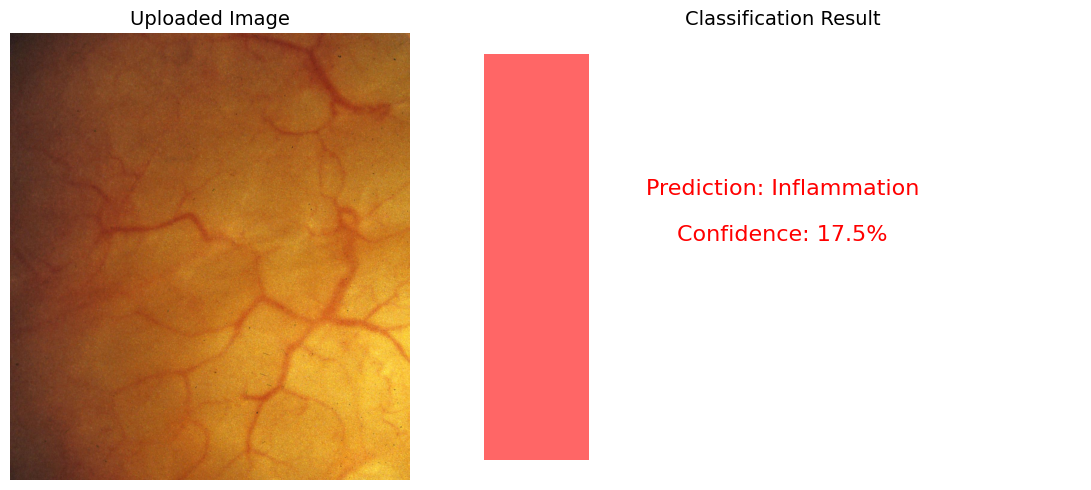

Result: Inflammation (17.5% confidence)

Please upload a cystoscopy image for classification (or cancel to exit):


Saving 528. Air bubbles at bladder roof.jpg to 528. Air bubbles at bladder roof.jpg

Processing: 528. Air bubbles at bladder roof.jpg


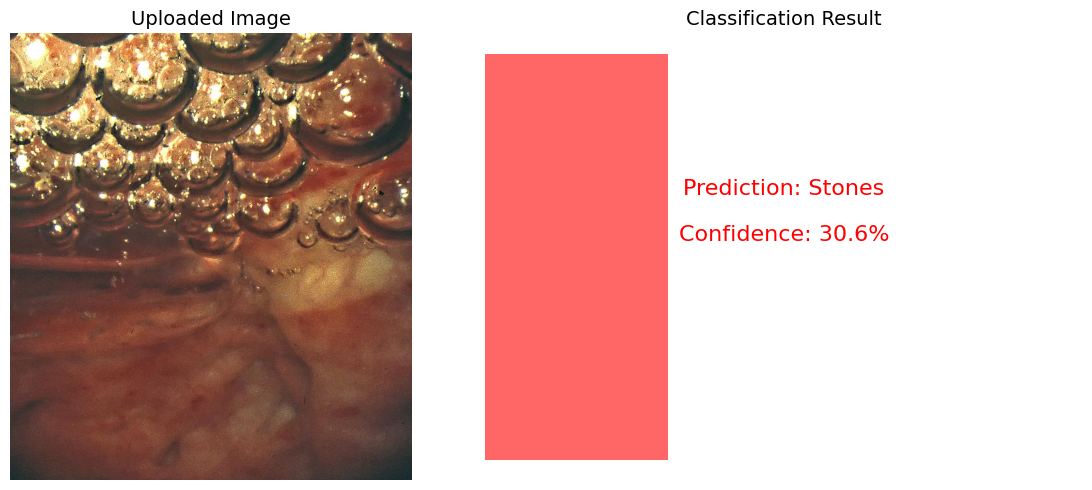

Result: Stones (30.6% confidence)

Please upload a cystoscopy image for classification (or cancel to exit):


No file uploaded. Exiting prediction tool.


In [ ]:
 # If you only want to run the prediction tool with a pre-trained model,
if __name__ == "__main__":

    # If you only want to run the prediction tool with a pre-trained model,
    # make sure config.MODEL_SAVE_PATH points to a valid .pth file
    run_prediction_only()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading dataset...
Found 7 classes: ['AbnormalVesselsBleeding', 'BladderNormal', 'BladderWallAlteration', 'Cancer', 'Diverticulum', 'Inflammation', 'Stones']
Dataset split: 484 train, 60 val, 62 test
Creating model with 7 output classes...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Best model loaded from /content/drive/MyDrive/Study/cystoscopy_model.pth

CYSTOSCOPY IMAGE CLASSIFICATION TOOL

Please upload a cystoscopy image for classification (or cancel to exit):


Saving 526. Difficult to see - ureteral orifice.jpg to 526. Difficult to see - ureteral orifice.jpg

Processing: 526. Difficult to see - ureteral orifice.jpg


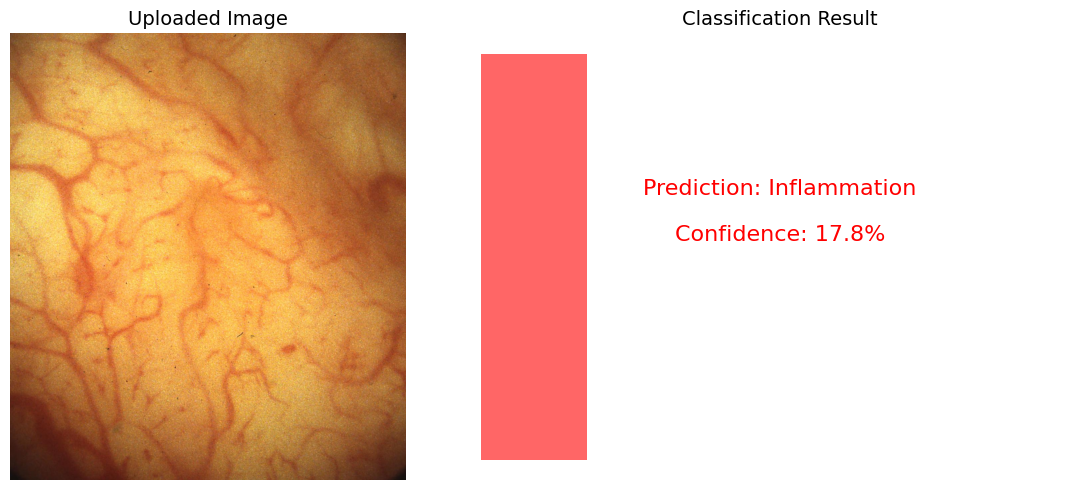

Result: Inflammation (17.8% confidence)

Please upload a cystoscopy image for classification (or cancel to exit):


Saving 530. Bladder - normal.jpg to 530. Bladder - normal.jpg

Processing: 530. Bladder - normal.jpg


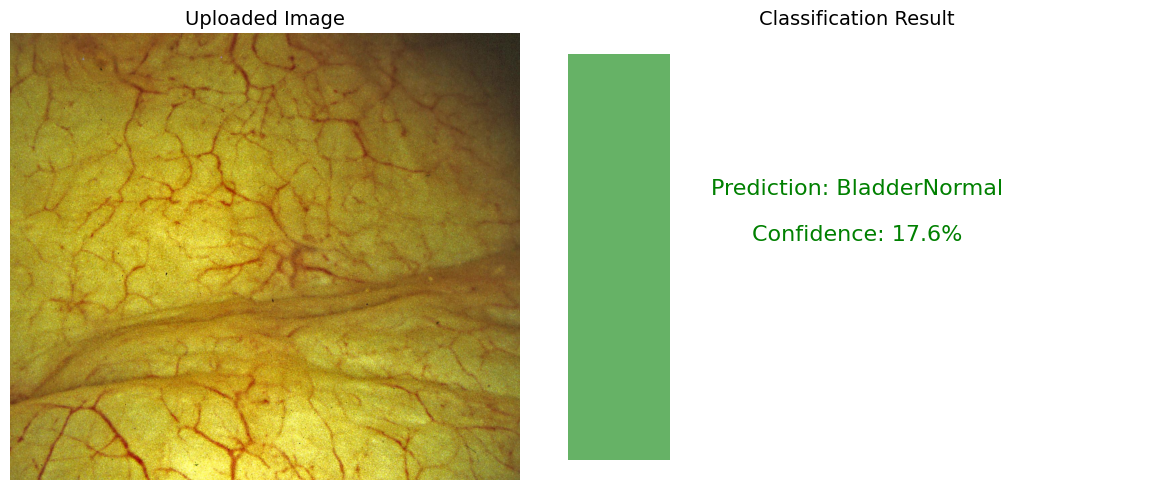

Result: BladderNormal (17.6% confidence)

Please upload a cystoscopy image for classification (or cancel to exit):


No file uploaded. Exiting prediction tool.


In [ ]:
# If you want to train the model and then predict, use main()
if __name__ == "__main__":

     main()
    # If you only want to run the prediction tool with a pre-trained model,
    # make sure config.MODEL_SAVE_PATH points to a valid .pth file
    run_prediction_only()










